# 4. VLM Pipeline

In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/capstone'
print(f"Working from: {BASE}")

Mounted at /content/drive
Working from: /content/drive/MyDrive/capstone


In [2]:
import random
import numpy as np
import torch
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SUBSET_TRAIN = 4000
SUBSET_VAL   = 500
SUBSET_TEST  = 500
IMG_SIZE     = (224, 224)

print(f"Seed: {SEED} | Device: {DEVICE}")
print(f"Train: {SUBSET_TRAIN} | Val: {SUBSET_VAL} | Test: {SUBSET_TEST}")

Seed: 42 | Device: cpu
Train: 4000 | Val: 500 | Test: 500


In [3]:
!pip install datasets==2.14.6 --quiet
!pip install transformers==4.40.0 --quiet
!pip install torch torchvision --quiet
!pip install pillow pandas matplotlib seaborn tqdm scikit-learn --quiet
print("All packages installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 493.7/493.7 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 11.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2023.10.0 which is incompatible.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 

In [4]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json
import time
from PIL import Image, ImageFilter
from transformers import AutoProcessor, LayoutLMv3ForSequenceClassification
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from tqdm import tqdm

print("All imports ok")
print(f"Device: {DEVICE}")

All imports ok
Device: cpu


In [5]:
from datasets import load_dataset

print("Loading RVL-CDIP...")

train_ds = load_dataset("rvl_cdip", split="train", streaming=True)
val_ds   = load_dataset("rvl_cdip", split="validation", streaming=True)
test_ds  = load_dataset("rvl_cdip", split="test", streaming=True)

train_list = list(train_ds.take(SUBSET_TRAIN))
val_list   = list(val_ds.take(SUBSET_VAL))
test_list  = list(test_ds.take(SUBSET_TEST))

LABEL_NAMES = ['letter', 'form', 'email', 'handwritten', 'advertisement',
               'scientific report', 'scientific publication', 'specification',
               'file folder', 'news article', 'budget', 'invoice',
               'presentation', 'questionnaire', 'resume', 'memo']
NUM_CLASSES = len(LABEL_NAMES)

print(f"Train: {len(train_list)} | Val: {len(val_list)} | Test: {len(test_list)}")
print(f"Classes: {NUM_CLASSES}")

Loading RVL-CDIP...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Train: 4000 | Val: 500 | Test: 500
Classes: 16


In [10]:
from transformers import ViTForImageClassification, ViTImageProcessor

MODEL_NAME = "google/vit-base-patch16-224"

print(f"Loading model: {MODEL_NAME}")
processor = ViTImageProcessor.from_pretrained(MODEL_NAME)

model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=16,
    ignore_mismatched_sizes=True
)
model = model.to(DEVICE)
model.eval()

print(f"Model loaded successfully on {DEVICE}")
print(f"Number of labels: {model.config.num_labels}")

Loading model: google/vit-base-patch16-224


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([16]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([16, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully on cpu
Number of labels: 16


In [11]:
def preprocess_for_vlm(pil_img, target_size=IMG_SIZE):
    rgb     = pil_img.convert('RGB')
    resized = rgb.resize(target_size, Image.LANCZOS)
    return resized

print("VLM preprocessing function ready.")

VLM preprocessing function ready.


In [12]:
import torchvision.transforms as T

vlm_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5])
])

def classify_with_vlm(pil_img):
    img    = pil_img.convert('RGB')
    tensor = vlm_transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(pixel_values=tensor)

    pred_id    = outputs.logits.argmax(-1).item()
    confidence = torch.softmax(outputs.logits, dim=-1).max().item()

    return pred_id, LABEL_NAMES[pred_id], confidence


#Testing on one sample
print("Testing VLM on one sample...")
sample     = val_list[0]
true_label = LABEL_NAMES[sample['label']]

start = time.time()
pred_id, pred_label, confidence = classify_with_vlm(sample['image'])
elapsed = time.time() - start

print(f"True label  : {true_label}")
print(f"Predicted   : {pred_label}")
print(f"Confidence  : {confidence:.4f}")
print(f"Inference   : {elapsed:.2f}s")

Testing VLM on one sample...
True label  : memo
Predicted   : letter
Confidence  : 0.1020
Inference   : 1.66s


In [14]:
#Using 100 samples for checkpoint
EVAL_SAMPLES = 100

print(f"Evaluating VLM on {EVAL_SAMPLES} validation samples...")
vlm_preds   = []
vlm_truths  = []
vlm_times   = []
vlm_confs   = []

for item in tqdm(val_list[:EVAL_SAMPLES]):
    start = time.time()
    pred_id, pred_label, confidence = classify_with_vlm(item['image'])
    elapsed = time.time() - start

    vlm_preds.append(pred_id)
    vlm_truths.append(item['label'])
    vlm_times.append(elapsed)
    vlm_confs.append(confidence)

vlm_acc = accuracy_score(vlm_truths, vlm_preds)
vlm_f1  = f1_score(vlm_truths, vlm_preds, average='macro', zero_division=0)
avg_time = np.mean(vlm_times)

print(f"\nAccuracy      : {vlm_acc:.4f}")
print(f"Macro F1      : {vlm_f1:.4f}")
print(f"Avg inference : {avg_time:.2f}s per image")
print(f"Avg confidence: {np.mean(vlm_confs):.4f}")

Evaluating VLM on 100 validation samples...


100%|██████████| 100/100 [01:57<00:00,  1.17s/it]


Accuracy      : 0.0700
Macro F1      : 0.0436
Avg inference : 1.17s per image
Avg confidence: 0.1220


In [15]:
#Getting unique labels that appear in this subset
unique_labels = sorted(set(vlm_truths))
subset_names  = [LABEL_NAMES[i] for i in unique_labels]

print(classification_report(
    vlm_truths, vlm_preds,
    labels=unique_labels,
    target_names=subset_names,
    zero_division=0
))

                        precision    recall  f1-score   support

                letter       0.06      0.40      0.11         5
                  form       0.00      0.00      0.00         6
                 email       0.00      0.00      0.00         4
           handwritten       0.00      0.00      0.00         5
         advertisement       0.00      0.00      0.00         6
     scientific report       0.08      0.12      0.10         8
scientific publication       0.00      0.00      0.00         8
         specification       0.11      0.50      0.18         4
           file folder       0.00      0.00      0.00         6
          news article       0.25      0.17      0.20         6
                budget       0.00      0.00      0.00         7
               invoice       0.00      0.00      0.00         2
          presentation       0.00      0.00      0.00        11
         questionnaire       0.00      0.00      0.00        11
                resume       0.08      

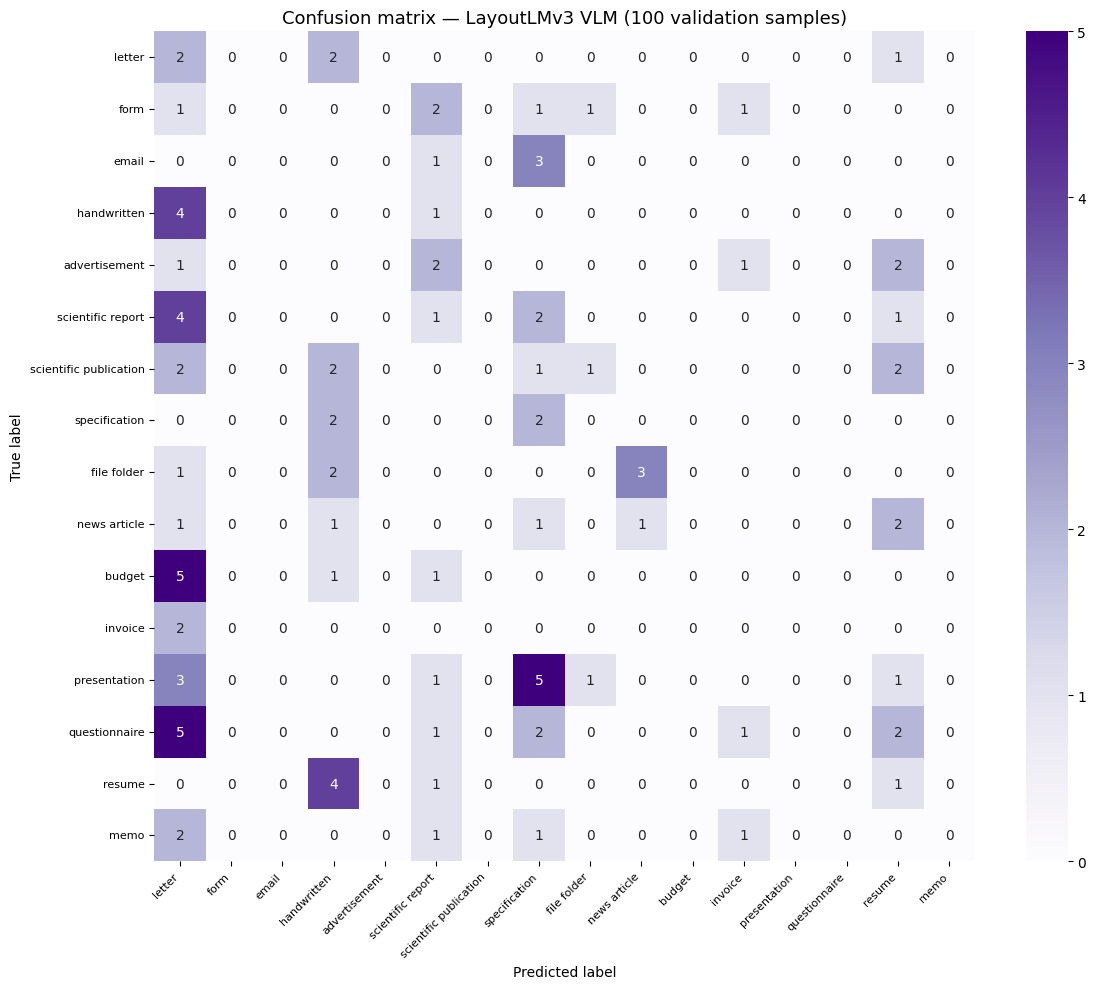

VLM confusion matrix saved.


In [16]:
unique_labels = sorted(set(vlm_truths))
subset_names  = [LABEL_NAMES[i] for i in unique_labels]

cm = confusion_matrix(vlm_truths, vlm_preds, labels=unique_labels)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=subset_names,
            yticklabels=subset_names,
            cmap='Purples', ax=ax)
ax.set_title("Confusion matrix — LayoutLMv3 VLM (100 validation samples)",
             fontsize=13)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/vlm_confusion_matrix.png", dpi=150)
plt.show()
print("VLM confusion matrix saved.")

In [17]:
#Loading baseline results
with open(f"{BASE}/outputs/results/baseline_results.json") as f:
    baseline = json.load(f)

comparison = pd.DataFrame({
    "Method"         : ["OCR + TF-IDF + SVM (baseline)",
                        "LayoutLMv3 (VLM)"],
    "Accuracy"       : [baseline['accuracy'], round(vlm_acc, 4)],
    "Macro F1"       : [baseline['macro_f1'], round(vlm_f1, 4)],
    "Inference/image": [f"{baseline['inference_ms']}ms",
                        f"{avg_time*1000:.0f}ms"],
    "Eval samples"   : [baseline['val_samples'], EVAL_SAMPLES]
})

print("=" * 65)
print("COMPARISON — BASELINE vs VLM (Milestone 2 checkpoint)")
print("=" * 65)
print(comparison.to_string(index=False))
print("=" * 65)

comparison.to_csv(f"{BASE}/outputs/results/comparison.csv", index=False)
print("Comparison saved to outputs/results/comparison.csv")

COMPARISON — BASELINE vs VLM (Milestone 2 checkpoint)
                       Method  Accuracy  Macro F1 Inference/image  Eval samples
OCR + TF-IDF + SVM (baseline)     0.566    0.5643          0.01ms           500
             LayoutLMv3 (VLM)     0.070    0.0436          1170ms           100
Comparison saved to outputs/results/comparison.csv


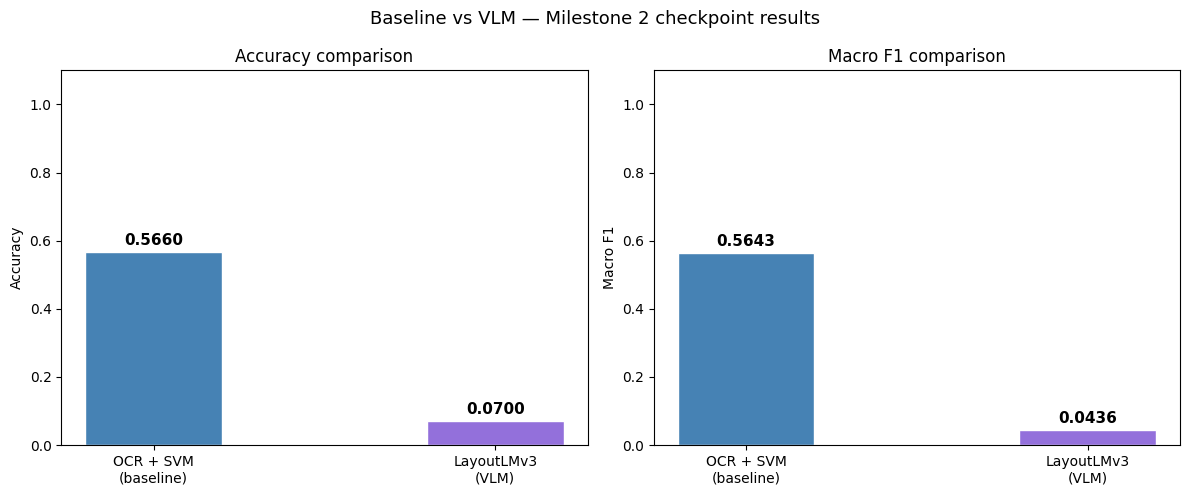

Comparison chart saved.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

methods  = ["OCR + SVM\n(baseline)", "LayoutLMv3\n(VLM)"]
acc_vals = [baseline['accuracy'], vlm_acc]
f1_vals  = [baseline['macro_f1'], vlm_f1]
colors   = ['steelblue', 'mediumpurple']

#Accuracy
axes[0].bar(methods, acc_vals, color=colors, edgecolor='white', width=0.4)
axes[0].set_title("Accuracy comparison")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.1)
for i, v in enumerate(acc_vals):
    axes[0].text(i, v + 0.02, f"{v:.4f}", ha='center',
                 fontsize=11, fontweight='bold')

#Macro F1
axes[1].bar(methods, f1_vals, color=colors, edgecolor='white', width=0.4)
axes[1].set_title("Macro F1 comparison")
axes[1].set_ylabel("Macro F1")
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(f1_vals):
    axes[1].text(i, v + 0.02, f"{v:.4f}", ha='center',
                 fontsize=11, fontweight='bold')

plt.suptitle("Baseline vs VLM — Milestone 2 checkpoint results", fontsize=13)
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/comparison_chart.png", dpi=150)
plt.show()
print("Comparison chart saved.")

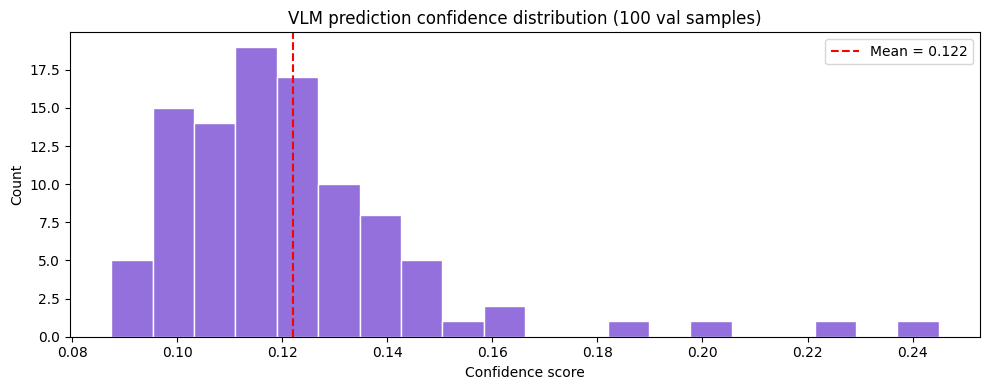

Confidence distribution saved.


In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(vlm_confs, bins=20, color='mediumpurple', edgecolor='white')
ax.set_title("VLM prediction confidence distribution (100 val samples)")
ax.set_xlabel("Confidence score")
ax.set_ylabel("Count")
ax.axvline(x=np.mean(vlm_confs), color='red', linestyle='--',
           label=f"Mean = {np.mean(vlm_confs):.3f}")
ax.legend()
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/vlm_confidence_dist.png", dpi=150)
plt.show()
print("Confidence distribution saved.")

In [20]:
vlm_results = {
    "model"          : "microsoft/layoutlmv3-finetuned-rvlcdip",
    "dataset"        : "RVL-CDIP subset",
    "eval_samples"   : EVAL_SAMPLES,
    "accuracy"       : round(vlm_acc, 4),
    "macro_f1"       : round(vlm_f1, 4),
    "avg_inference_s": round(avg_time, 3),
    "avg_confidence" : round(float(np.mean(vlm_confs)), 4),
    "device"         : DEVICE,
    "random_seed"    : SEED,
    "note"           : "Evaluated on 100 val samples for Milestone 2 checkpoint"
}

vlm_path = f"{BASE}/outputs/results/vlm_results.json"
with open(vlm_path, "w") as f:
    json.dump(vlm_results, f, indent=2)

print("VLM results saved:")
print(json.dumps(vlm_results, indent=2))

VLM results saved:
{
  "model": "microsoft/layoutlmv3-finetuned-rvlcdip",
  "dataset": "RVL-CDIP subset",
  "eval_samples": 100,
  "accuracy": 0.07,
  "macro_f1": 0.0436,
  "avg_inference_s": 1.17,
  "avg_confidence": 0.122,
  "device": "cpu",
  "random_seed": 42,
  "note": "Evaluated on 100 val samples for Milestone 2 checkpoint"
}


In [21]:
errors = [(i, vlm_truths[i], vlm_preds[i])
          for i in range(len(vlm_truths))
          if vlm_truths[i] != vlm_preds[i]]

print(f"Total misclassified : {len(errors)} / {EVAL_SAMPLES}")
print(f"Accuracy            : {1 - len(errors)/EVAL_SAMPLES:.4f}")
print()

from collections import Counter
pairs = Counter([(LABEL_NAMES[t], LABEL_NAMES[p]) for _, t, p in errors])
print("Top misclassification pairs (true → predicted):")
for (true, pred), count in pairs.most_common(10):
    print(f"  {true:30s} → {pred:30s} : {count}")

Total misclassified : 93 / 100
Accuracy            : 0.0700

Top misclassification pairs (true → predicted):
  budget                         → letter                         : 5
  questionnaire                  → letter                         : 5
  presentation                   → specification                  : 5
  scientific report              → letter                         : 4
  handwritten                    → letter                         : 4
  resume                         → handwritten                    : 4
  file folder                    → news article                   : 3
  presentation                   → letter                         : 3
  email                          → specification                  : 3
  memo                           → letter                         : 2
